
# Direction U: External multi-drug validation + leakage-aware check

Notebook này phát triển tiếp từ Direction S/T.

**Ý tưởng chính:** Direction T đã proof được TET external. Direction U mở rộng thành kiểm chứng external nhiều thuốc mới như **TET, CIP, STR, GEN, NAL**, đồng thời thêm kiểm tra chắc hơn:

1. Chạy external proof cho nhiều thuốc mới, không chỉ TET.
2. Dùng repeated train/validation/test split để có mean ± std.
3. Tùy chọn split theo group metadata để giảm nguy cơ leakage do các genome quá giống nhau hoặc cùng nguồn.
4. Tự động tổng hợp top feature ổn định và đánh dấu feature có keyword liên quan cơ chế kháng thuốc.
5. Xuất bảng kết quả để bổ sung vào báo cáo/slide cuối.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

# =========================
# 0. Import + config
# =========================

import os
import re
import json
import time
import math
import shutil
import warnings
from pathlib import Path
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import display, Markdown

import requests

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

BASE_DIR = Path("/content/salmonella_direction_U_external_multidrug")
REPO_DIR = BASE_DIR / "AMRMetadataReview_2021"
OUTPUT_DIR = BASE_DIR / "outputs"
CACHE_DIR = BASE_DIR / "cache_bvbrc_features"

for d in [BASE_DIR, OUTPUT_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Thuốc external muốn kiểm chứng. Có thể bỏ bớt nếu API chạy lâu.
TARGET_DRUGS = [
    {"drug_code": "TET", "contains": "tetracycline", "drug_class": "tetracycline"},
    {"drug_code": "CIP", "contains": "ciprofloxacin", "drug_class": "fluoroquinolone"},
    {"drug_code": "STR", "contains": "streptomycin", "drug_class": "aminoglycoside"},
    {"drug_code": "GEN", "contains": "gentamicin", "drug_class": "aminoglycoside"},
    {"drug_code": "NAL", "contains": "nalidixic acid", "drug_class": "quinolone"},
]

# Để chạy nhanh, đặt 200-300. Nếu API ổn, tăng lên 500 hoặc 1000.
N_PER_CLASS = 250
N_REPEATS = 5
RANDOM_SEED = 42

# Feature selection + model
K_FEATURES_LIST = [100, 200, 500]
TEST_SIZE = 0.20
VAL_SIZE = 0.25
RUN_GROUP_AWARE_SPLIT = True
RUN_NEGATIVE_CONTROL = True

# API BV-BRC genome_feature
API_BASE = "https://www.bv-brc.org/api"
FEATURE_FIELDS = [
    "genome_id",
    "patric_id",
    "feature_id",
    "feature_type",
    "gene",
    "product",
    "pgfam_id",
    "plfam_id",
]
API_SLEEP = 0.10
API_LIMIT_PER_QUERY = 50000

print("HAS_XGB:", HAS_XGB)
print("BASE_DIR:", BASE_DIR)
print("TARGET_DRUGS:", [d["drug_code"] for d in TARGET_DRUGS])
print("N_PER_CLASS:", N_PER_CLASS, "N_REPEATS:", N_REPEATS)


HAS_XGB: True
BASE_DIR: /content/salmonella_direction_U_external_multidrug
TARGET_DRUGS: ['TET', 'CIP', 'STR', 'GEN', 'NAL']
N_PER_CLASS: 250 N_REPEATS: 5



## 1. Lấy metadata AMR external từ BV-BRC/PATRIC

Cell dưới clone repo `BV-BRC/AMRMetadataReview_2021`, đọc các bảng tabular, chuẩn hóa thành long table gồm: `genome_id`, `genome_name`, `antibiotic`, `drug_code`, `phenotype`, và một số cột metadata nếu có.


In [3]:

# =========================
# 1. Clone AMR metadata repo
# =========================

if not REPO_DIR.exists():
    !git clone --depth 1 https://github.com/BV-BRC/AMRMetadataReview_2021.git "{REPO_DIR}"
else:
    print("Repo đã tồn tại:", REPO_DIR)

print("Một số file tabular:")
!find "{REPO_DIR}/tabular" -maxdepth 1 -type f | head -20


Cloning into '/content/salmonella_direction_U_external_multidrug/AMRMetadataReview_2021'...
remote: Enumerating objects: 102, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 102 (delta 23), reused 102 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (102/102), 559.36 MiB | 23.06 MiB/s, done.
Resolving deltas: 100% (23/23), done.
Updating files: 100% (95/95), done.
Một số file tabular:
/content/salmonella_direction_U_external_multidrug/AMRMetadataReview_2021/tabular/AMR.tbl.v4
/content/salmonella_direction_U_external_multidrug/AMRMetadataReview_2021/tabular/amr.mic.filt.tab
/content/salmonella_direction_U_external_multidrug/AMRMetadataReview_2021/tabular/README.md
/content/salmonella_direction_U_external_multidrug/AMRMetadataReview_2021/tabular/amr.sir.filt.tab


In [4]:

# =========================
# 2. Đọc AMR long table và lọc Salmonella
# =========================

tabular_dir = REPO_DIR / "tabular"
files = sorted([p for p in tabular_dir.glob("*") if p.is_file()])


def read_any_table(path):
    path = Path(path)
    df = pd.read_csv(path, sep="\t", low_memory=False)
    if df.shape[1] == 1:
        df = pd.read_csv(path, low_memory=False)
    return df


def norm_col(c):
    return re.sub(r"[^a-z0-9]+", "_", str(c).lower()).strip("_")


def find_col(df, keywords):
    for c in df.columns:
        nc = norm_col(c)
        if all(k in nc for k in keywords):
            return c
    return None


def find_col_any(df, list_of_keyword_lists):
    for kws in list_of_keyword_lists:
        c = find_col(df, kws)
        if c is not None:
            return c
    return None


def infer_columns(df):
    return {
        "genome_id": find_col_any(df, [["genome", "id"], ["genome_id"], ["genome"]]),
        "genome_name": find_col_any(df, [["genome", "name"], ["genome_name"], ["organism", "name"], ["organism"], ["species"], ["taxon", "name"], ["taxon"]]),
        "antibiotic": find_col_any(df, [["antibiotic"], ["drug"], ["antimicrobial"]]),
        "phenotype": find_col_any(df, [["resistant", "phenotype"], ["phenotype"], ["sir"], ["resistance"]]),
        "serovar": find_col_any(df, [["serovar"], ["serotype"]]),
        "isolation_source": find_col_any(df, [["isolation", "source"], ["source"]]),
        "collection_date": find_col_any(df, [["collection", "date"], ["date"]]),
        "country": find_col_any(df, [["country"]]),
        "host": find_col_any(df, [["host"]]),
    }


def parse_sir_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in ["r", "resistant", "resistance", "non-susceptible", "nonsusceptible"]:
        return "R"
    if s in ["s", "susceptible", "sensitive", "susceptibility"]:
        return "S"
    if s in ["i", "intermediate"]:
        return "I"
    if "resistant" in s and "suscept" not in s:
        return "R"
    if "suscept" in s or "sensitive" in s:
        return "S"
    if "intermediate" in s:
        return "I"
    return np.nan


def normalize_antibiotic_name(x):
    s = str(x).strip()
    s = re.sub(r":.*$", "", s)
    s = s.replace("_", " ").replace("-", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s


ANTIBIOTIC_SYNONYMS = {
    "tetracycline": "TET",
    "ciprofloxacin": "CIP",
    "streptomycin": "STR",
    "gentamicin": "GEN",
    "nalidixic acid": "NAL",
    "kanamycin": "KAN",
    "ceftiofur": "CEF",
    "sulfisoxazole": "FIS",
    "trimethoprim sulphamethoxazole": "SXT",
    "trimethoprim sulfamethoxazole": "SXT",
    "trimethoprim-sulfamethoxazole": "SXT",
    "trimethoprim/sulfamethoxazole": "SXT",
    "amoxicillin clavulanic acid": "AMC",
    "amoxicillin-clavulanic acid": "AMC",
}


def antibiotic_code(name):
    s = normalize_antibiotic_name(name).lower()
    if s in ANTIBIOTIC_SYNONYMS:
        return ANTIBIOTIC_SYNONYMS[s]
    for key, code in ANTIBIOTIC_SYNONYMS.items():
        if key in s:
            return code
    return re.sub(r"[^A-Za-z]", "", s).upper()[:3]


long_tables = []

for p in files:
    try:
        df = read_any_table(p)
        cols = infer_columns(df)
        if cols["genome_id"] and cols["antibiotic"] and cols["phenotype"]:
            tmp = pd.DataFrame()
            tmp["source_file"] = p.name
            tmp["genome_id"] = df[cols["genome_id"]].astype(str)
            tmp["genome_name"] = df[cols["genome_name"]].astype(str) if cols["genome_name"] else ""
            tmp["antibiotic_raw"] = df[cols["antibiotic"]]
            tmp["antibiotic"] = df[cols["antibiotic"]].map(normalize_antibiotic_name)
            tmp["drug_code"] = tmp["antibiotic"].map(antibiotic_code)
            tmp["phenotype"] = df[cols["phenotype"]].map(parse_sir_value)
            for out_col in ["serovar", "isolation_source", "collection_date", "country", "host"]:
                if cols.get(out_col):
                    tmp[out_col] = df[cols[out_col]].astype(str)
                else:
                    tmp[out_col] = ""
            long_tables.append(tmp)
            print("OK:", p.name, tmp.shape)
    except Exception as e:
        print("Skip:", p.name, repr(e)[:200])

if not long_tables:
    raise RuntimeError("Không đọc được bảng AMR nào. Kiểm tra repo/tabular.")

amr = pd.concat(long_tables, ignore_index=True)
amr = amr.dropna(subset=["genome_id", "antibiotic", "phenotype"])
amr = amr[amr["phenotype"].isin(["S", "R"])].copy()

# Ưu tiên lọc Salmonella bằng genome_name; nếu genome_name thiếu thì dùng source table đã là Salmonella nếu có.
salm = amr[amr["genome_name"].str.contains("salmonella", case=False, na=False)].copy()
if len(salm) == 0:
    salm = amr[amr["source_file"].str.contains("salmonella", case=False, na=False)].copy()

# Deduplicate same genome-drug. Nếu có conflict, lấy phenotype xuất hiện nhiều hơn.
def resolve_duplicate(g):
    vc = g["phenotype"].value_counts()
    keep = vc.index[0]
    row = g.iloc[0].copy()
    row["phenotype"] = keep
    row["n_duplicate_rows"] = len(g)
    row["has_conflict"] = int(g["phenotype"].nunique() > 1)
    return row

salm = (
    salm
    .groupby(["genome_id", "drug_code"], as_index=False, group_keys=False)
    .apply(resolve_duplicate)
    .reset_index(drop=True)
)

print("AMR rows:", amr.shape)
print("Salmonella S/R unique genome-drug rows:", salm.shape)
print("Phenotype counts:")
print(salm["phenotype"].value_counts())

display(salm.head())
salm.to_csv(OUTPUT_DIR / "direction_U_salmonella_external_long_table.csv", index=False)


OK: AMR.tbl.v4 (550802, 12)
Skip: README.md ParserError('Error tokenizing data. C error: Expected 1 fields in line 4, saw 3\n')
AMR rows: (348230, 12)
Salmonella S/R unique genome-drug rows: (39313, 14)
Phenotype counts:
phenotype
S    30152
R     9161
Name: count, dtype: int64


,source_file,genome_id,genome_name,antibiotic_raw,antibiotic,drug_code,phenotype,serovar,isolation_source,collection_date,country,host,n_duplicate_rows,has_conflict
0,NaN,1079901.3,Salmonella enterica subsp. enterica serovar Hi...,amoxicillin_clavulanic_acid,amoxicillin clavulanic acid,AMC,S,,nan,,,,1,0
1,NaN,1079901.3,Salmonella enterica subsp. enterica serovar Hi...,ampicillin,ampicillin,AMP,R,,nan,,,,1,0
2,NaN,1079901.3,Salmonella enterica subsp. enterica serovar Hi...,azithromycin,azithromycin,AZI,S,,nan,,,,1,0
3,NaN,1079901.3,Salmonella enterica subsp. enterica serovar Hi...,cefoxitin,cefoxitin,CEF,R,,nan,,,,3,1
4,NaN,1079901.3,Salmonella enterica subsp. enterica serovar Hi...,chloramphenicol,chloramphenicol,CHL,S,,nan,,,,1,0



## 2. Chọn candidate thuốc mới

Notebook ưu tiên các thuốc có đủ S/R để tránh kết quả bị lệch lớp quá nặng. Nếu muốn chạy nhanh, giữ TET + CIP + STR trước; nếu muốn mạnh hơn, chạy thêm GEN/NAL/KAN/SXT.


In [5]:

# =========================
# 3. Candidate drug summary
# =========================

drug_summary = (
    salm
    .groupby(["antibiotic", "drug_code", "phenotype"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ["S", "R"]:
    if col not in drug_summary.columns:
        drug_summary[col] = 0

drug_summary["n_total_SR"] = drug_summary["S"] + drug_summary["R"]
drug_summary["resistant_rate"] = drug_summary["R"] / drug_summary["n_total_SR"].replace(0, np.nan)
drug_summary = drug_summary.sort_values("n_total_SR", ascending=False)

candidate_summary = drug_summary[(drug_summary["S"] >= 50) & (drug_summary["R"] >= 50)].copy()

display(candidate_summary.head(30))
candidate_summary.to_csv(OUTPUT_DIR / "direction_U_candidate_external_drugs.csv", index=False)


phenotype,antibiotic,drug_code,R,S,n_total_SR,resistant_rate
2,ampicillin,AMP,1465,2209,3674,0.398748
14,chloramphenicol,CHL,744,2902,3646,0.204059
15,ciprofloxacin,CIP,627,2681,3308,0.189541
41,trimethoprim sulphamethoxazole,SXT,371,2643,3014,0.123092
37,tetracycline,TET,1545,1322,2867,0.538891
26,nalidixic acid,NAL,255,2570,2825,0.090265
32,streptomycin,STR,1200,1605,2805,0.427807
21,gentamicin,GEN,309,2307,2616,0.118119
9,cefoxitin,CEF,360,1873,2233,0.161218
1,amoxicillin clavulanic acid,AMC,387,1842,2229,0.173620



## 3. Lấy genome annotation features từ BV-BRC

Không tải raw FASTQ/FASTA. Mỗi genome được query qua BV-BRC `genome_feature` API, rồi chuyển thành token presence/absence từ `pgfam_id`, `plfam_id`, `gene`, `product`.

Có cache trong `cache_bvbrc_features`, nên chạy lại sẽ nhanh hơn.


In [6]:

# =========================
# 4. BV-BRC genome_feature API functions
# =========================


def clean_feature_token(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    if s == "" or s in ["nan", "none", "hypothetical protein"]:
        return None
    s = re.sub(r"[^a-z0-9_\-\.]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    if len(s) < 2:
        return None
    return s[:140]


def features_to_tokens(df):
    tokens = []
    for _, r in df.iterrows():
        for col, prefix in [
            ("pgfam_id", "pgfam"),
            ("plfam_id", "plfam"),
            ("gene", "gene"),
            ("product", "prod"),
        ]:
            if col in df.columns:
                tok = clean_feature_token(r.get(col))
                if tok:
                    tokens.append(f"{prefix}:{tok}")
    return sorted(set(tokens))


def fetch_features_for_genome_eq(genome_id):
    select = ",".join(FEATURE_FIELDS)
    url = f"{API_BASE}/genome_feature/?eq(genome_id,{genome_id})&select({select})&limit({API_LIMIT_PER_QUERY})"
    headers = {"Accept": "application/json"}
    r = requests.get(url, headers=headers, timeout=90)
    if r.status_code != 200:
        raise RuntimeError(f"HTTP {r.status_code}: {r.text[:300]}")
    return r.json()


def fetch_features_for_genome(genome_id):
    safe_id = str(genome_id).replace(".", "_").replace("/", "_")
    cache_file = CACHE_DIR / f"features_{safe_id}.json"
    if cache_file.exists():
        with open(cache_file, "r", encoding="utf-8") as f:
            return json.load(f)

    data = fetch_features_for_genome_eq(genome_id)
    with open(cache_file, "w", encoding="utf-8") as f:
        json.dump(data, f)
    time.sleep(API_SLEEP)
    return data


def genome_features_to_token_list(genome_id):
    try:
        data = fetch_features_for_genome(genome_id)
        if isinstance(data, dict) and "response" in data and "docs" in data["response"]:
            rows = data["response"]["docs"]
        elif isinstance(data, list):
            rows = data
        else:
            rows = []
        df = pd.DataFrame(rows)
        if len(df) == 0:
            return []
        if "feature_type" in df.columns:
            df2 = df[df["feature_type"].astype(str).str.lower().isin(["cds", "peg", "protein"])]
            if len(df2) > 0:
                df = df2
        return features_to_tokens(df)
    except Exception as e:
        return []


def fetch_tokens_for_genomes(genome_ids, progress_every=20):
    tokens_by_genome = {}
    failed = []
    genome_ids = list(map(str, genome_ids))
    for i, gid in enumerate(genome_ids, 1):
        if i % progress_every == 0 or i == 1 or i == len(genome_ids):
            print(f"Fetching {i}/{len(genome_ids)}...")
        toks = genome_features_to_token_list(gid)
        if len(toks) == 0:
            failed.append(gid)
        tokens_by_genome[gid] = toks
    print("Done. Empty/failed:", len(failed), "of", len(genome_ids))
    return tokens_by_genome, failed



## 4. Modeling functions

Điểm quan trọng: chọn feature chỉ trên train, tune threshold trên validation, cuối cùng báo cáo trên test. Như vậy tránh leakage từ test vào feature selection.


In [7]:

# =========================
# 5. Evaluation helpers
# =========================


def safe_scores(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auroc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "auprc": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
    }


def choose_threshold(y_val, prob_val, objective="f1"):
    thresholds = np.linspace(0.05, 0.95, 91)
    best_t, best_score = 0.5, -1
    for t in thresholds:
        pred = (prob_val >= t).astype(int)
        if objective == "balanced_accuracy":
            sc = balanced_accuracy_score(y_val, pred)
        else:
            sc = f1_score(y_val, pred, zero_division=0)
        if sc > best_score:
            best_score = sc
            best_t = t
    return float(best_t), float(best_score)


def select_chi2_topk(X_train, y_train, k):
    k = min(k, X_train.shape[1])
    scores, _ = chi2(X_train.clip(lower=0), y_train)
    s = pd.Series(scores, index=X_train.columns).replace([np.inf, -np.inf], np.nan).fillna(0)
    return list(s.sort_values(ascending=False).head(k).index)


def make_model(model_name, y_train, seed):
    if model_name == "LR_balanced":
        return LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs", random_state=seed)
    if model_name == "RF_balanced":
        return RandomForestClassifier(
            n_estimators=350,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=seed,
            n_jobs=-1,
        )
    if model_name == "XGB_weighted":
        if not HAS_XGB:
            raise RuntimeError("xgboost chưa được cài")
        pos = max(int(np.sum(y_train)), 1)
        neg = max(int(len(y_train) - np.sum(y_train)), 1)
        return xgb.XGBClassifier(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.04,
            subsample=0.85,
            colsample_bytree=0.85,
            eval_metric="logloss",
            scale_pos_weight=neg / pos,
            random_state=seed,
            n_jobs=-1,
        )
    raise ValueError(model_name)


def make_group_label(df):
    # group-aware split để giảm khả năng các mẫu cùng nguồn/cùng type nằm cả train và test.
    # Không phải metadata nào cũng có đủ cột, nên dùng các cột có sẵn.
    possible_cols = ["serovar", "isolation_source", "country", "host", "source_file"]
    use_cols = [c for c in possible_cols if c in df.columns and df[c].astype(str).str.len().mean() > 0]
    if not use_cols:
        return None
    group = df[use_cols].fillna("").astype(str).agg("|".join, axis=1)
    # Nếu quá ít group hoặc mỗi group gần như unique, group split không hữu ích.
    if group.nunique() < 5:
        return None
    return group.values


def group_train_test_split(X, y, groups, test_size, seed, max_try=100):
    # GroupShuffleSplit không stratify, nên retry để train/test có cả hai lớp.
    for t in range(max_try):
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed + t)
        train_idx, test_idx = next(gss.split(X, y, groups=groups))
        if len(np.unique(y[train_idx])) == 2 and len(np.unique(y[test_idx])) == 2:
            return train_idx, test_idx
    return None, None


def evaluate_one_matrix(X_all, y, model_df, drug_code, split_mode="stratified_random"):
    model_names = ["LR_balanced", "RF_balanced"]
    if HAS_XGB:
        model_names.append("XGB_weighted")

    y = np.asarray(y).astype(int)
    all_rows = []
    top_feature_records = []
    groups = make_group_label(model_df)

    for repeat in range(N_REPEATS):
        seed = RANDOM_SEED + repeat * 100

        if split_mode == "group_aware":
            if groups is None:
                continue
            trainval_idx, test_idx = group_train_test_split(X_all, y, groups, TEST_SIZE, seed)
            if trainval_idx is None:
                continue
            X_trainval = X_all.iloc[trainval_idx]
            X_test = X_all.iloc[test_idx]
            y_trainval = y[trainval_idx]
            y_test = y[test_idx]
        else:
            X_trainval, X_test, y_trainval, y_test = train_test_split(
                X_all, y, test_size=TEST_SIZE, random_state=seed, stratify=y
            )

        X_train, X_val, y_train, y_val = train_test_split(
            X_trainval, y_trainval, test_size=VAL_SIZE, random_state=seed + 1000, stratify=y_trainval
        )

        for k in K_FEATURES_LIST:
            selected = select_chi2_topk(X_train, y_train, k=k)

            for rank, feat in enumerate(selected[:100], 1):
                top_feature_records.append({
                    "drug_code": drug_code,
                    "split_mode": split_mode,
                    "repeat": repeat,
                    "k_features": k,
                    "rank": rank,
                    "feature": feat,
                })

            Xtr = X_train[selected]
            Xva = X_val[selected]
            Xte = X_test[selected]

            for model_name in model_names:
                model = make_model(model_name, y_train, seed)
                model.fit(Xtr, y_train)

                prob_val = model.predict_proba(Xva)[:, 1]
                threshold, val_score = choose_threshold(y_val, prob_val, objective="f1")

                prob_test = model.predict_proba(Xte)[:, 1]
                pred_test = (prob_test >= threshold).astype(int)
                sc = safe_scores(y_test, pred_test, prob_test)

                row = {
                    "drug_code": drug_code,
                    "split_mode": split_mode,
                    "repeat": repeat,
                    "model": model_name,
                    "k_features": k,
                    "threshold": threshold,
                    "val_f1_at_threshold": val_score,
                    "n_train": len(y_train),
                    "n_val": len(y_val),
                    "n_test": len(y_test),
                    "test_pos_rate": float(np.mean(y_test)),
                }
                row.update(sc)
                all_rows.append(row)

    return pd.DataFrame(all_rows), pd.DataFrame(top_feature_records)


def run_negative_control(X_all, y, model_df, drug_code):
    rng = np.random.default_rng(RANDOM_SEED + 999)
    y_shuffled = rng.permutation(np.asarray(y).astype(int))
    original_repeats = globals()["N_REPEATS"]
    original_k = globals()["K_FEATURES_LIST"]
    globals()["N_REPEATS"] = min(3, original_repeats)
    globals()["K_FEATURES_LIST"] = [min(200, X_all.shape[1])]
    try:
        neg_results, _ = evaluate_one_matrix(X_all, y_shuffled, model_df, drug_code, split_mode="stratified_random")
        neg_results["negative_control"] = 1
    finally:
        globals()["N_REPEATS"] = original_repeats
        globals()["K_FEATURES_LIST"] = original_k
    return neg_results



## 5. Feature interpretation helpers

Keyword matching không thay thế được CARD/ResFinder/AMRFinderPlus, nhưng đủ để tạo lớp diễn giải nhanh: feature nào có tên gợi ý đúng cơ chế kháng thuốc.


In [8]:

# =========================
# 6. Top feature interpretation
# =========================

DRUG_KEYWORDS = {
    "TET": ["tet", "tetracycline", "efflux", "mfs"],
    "CIP": ["ciprofloxacin", "quinolone", "gyr", "parc", "pare", "qnr", "aac_6", "efflux", "acr", "mar"],
    "NAL": ["nalidixic", "quinolone", "gyr", "parc", "pare", "qnr", "efflux", "acr", "mar"],
    "STR": ["streptomycin", "stra", "strb", "aada", "aad", "aminoglycoside", "aph", "ant"],
    "GEN": ["gentamicin", "aminoglycoside", "aac", "aph", "aad", "ant", "efflux"],
    "SXT": ["sul", "folp", "dfr", "trimethoprim", "sulfamethoxazole"],
}

GENERAL_AMR_KEYWORDS = [
    "resistance", "resistant", "beta_lactamase", "lactamase", "efflux", "transporter",
    "mfs", "acr", "mar", "integrase", "transposase", "plasmid", "mobile", "is_element",
]


def annotate_feature_keyword(feature, drug_code):
    s = str(feature).lower()
    drug_hits = [kw for kw in DRUG_KEYWORDS.get(drug_code, []) if kw in s]
    general_hits = [kw for kw in GENERAL_AMR_KEYWORDS if kw in s]
    if drug_hits:
        label = "drug_mechanism_keyword"
    elif general_hits:
        label = "general_amr_or_mobile_keyword"
    else:
        label = "unknown_by_keyword"
    return label, ";".join(drug_hits), ";".join(general_hits)


def summarize_top_features(top_df, drug_code, split_mode="stratified_random", top_n=50):
    if top_df.empty:
        return pd.DataFrame()
    sub = top_df[(top_df["drug_code"] == drug_code) & (top_df["split_mode"] == split_mode)].copy()
    if sub.empty:
        return pd.DataFrame()
    summary = (
        sub.groupby("feature")
        .agg(
            selected_count=("feature", "size"),
            mean_rank=("rank", "mean"),
            min_rank=("rank", "min"),
        )
        .reset_index()
        .sort_values(["selected_count", "mean_rank"], ascending=[False, True])
        .head(top_n)
    )
    ann = summary["feature"].apply(lambda f: annotate_feature_keyword(f, drug_code))
    summary["keyword_label"] = [a[0] for a in ann]
    summary["drug_keyword_hits"] = [a[1] for a in ann]
    summary["general_keyword_hits"] = [a[2] for a in ann]
    return summary



## 6. Chạy Direction U cho nhiều thuốc external

Cell này có thể chạy lâu vì fetch features qua API. Sau lần đầu, cache sẽ giúp chạy lại nhanh hơn.

Gợi ý chạy thử nhanh:

```python
TARGET_DRUGS = TARGET_DRUGS[:3]  # TET, CIP, STR
N_PER_CLASS = 200
N_REPEATS = 3
```


In [9]:

# =========================
# 7. Main loop — external multi-drug validation
# =========================

all_metric_rows = []
all_top_rows = []
all_neg_rows = []
all_drug_dataset_rows = []

for spec in TARGET_DRUGS:
    drug_code = spec["drug_code"]
    contains = spec["contains"]
    print("\n" + "=" * 80)
    print(f"DRUG {drug_code} — {contains}")
    print("=" * 80)

    target = salm[
        (salm["drug_code"] == drug_code) |
        (salm["antibiotic"].str.contains(contains, case=False, na=False))
    ].copy()

    target = target.drop_duplicates(subset=["genome_id"]).copy()
    counts = target["phenotype"].value_counts().to_dict()
    print("Raw target rows:", target.shape, counts)

    if target["phenotype"].nunique() < 2:
        print("Skip: không đủ S/R")
        continue

    S_df = target[target["phenotype"] == "S"].copy()
    R_df = target[target["phenotype"] == "R"].copy()
    n_each = min(N_PER_CLASS, len(S_df), len(R_df))
    if n_each < 50:
        print("Skip: quá ít mẫu mỗi lớp", n_each)
        continue

    S_sample = S_df.sample(n=n_each, random_state=RANDOM_SEED)
    R_sample = R_df.sample(n=n_each, random_state=RANDOM_SEED)
    target_balanced = pd.concat([S_sample, R_sample], ignore_index=True)
    target_balanced = target_balanced.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    target_balanced["y"] = (target_balanced["phenotype"] == "R").astype(int)

    target_balanced.to_csv(OUTPUT_DIR / f"direction_U_{drug_code}_balanced_subset.csv", index=False)

    genome_ids = target_balanced["genome_id"].astype(str).tolist()
    tokens_by_genome, failed = fetch_tokens_for_genomes(genome_ids, progress_every=25)

    with open(OUTPUT_DIR / f"direction_U_{drug_code}_tokens_by_genome.json", "w", encoding="utf-8") as f:
        json.dump(tokens_by_genome, f)

    valid_rows = []
    token_lists = []
    for _, row in target_balanced.iterrows():
        gid = str(row["genome_id"])
        toks = tokens_by_genome.get(gid, [])
        if len(toks) == 0:
            continue
        valid_rows.append(row.to_dict())
        token_lists.append(toks)

    model_df = pd.DataFrame(valid_rows)
    if len(model_df) < 80 or model_df["y"].nunique() < 2:
        print("Skip: usable rows quá ít sau khi fetch features", model_df.shape)
        continue

    y = model_df["y"].astype(int).values
    mlb = MultiLabelBinarizer(sparse_output=False)
    X_all = pd.DataFrame(
        mlb.fit_transform(token_lists),
        columns=mlb.classes_,
        index=model_df["genome_id"].astype(str).values,
    ).astype(np.int8)

    print("Usable model_df:", model_df.shape)
    print("X_all:", X_all.shape)
    print("Class counts:", pd.Series(y).value_counts().to_dict())

    model_df.to_csv(OUTPUT_DIR / f"direction_U_{drug_code}_model_rows.csv", index=False)
    # Ma trận feature có thể rất lớn; lưu parquet nếu có pyarrow, nếu không lưu csv.gz.
    try:
        X_all.to_parquet(OUTPUT_DIR / f"direction_U_{drug_code}_feature_matrix.parquet")
    except Exception:
        X_all.to_csv(OUTPUT_DIR / f"direction_U_{drug_code}_feature_matrix.csv.gz", compression="gzip")

    dataset_row = {
        "drug_code": drug_code,
        "antibiotic_contains": contains,
        "raw_rows": len(target),
        "raw_S": int((target["phenotype"] == "S").sum()),
        "raw_R": int((target["phenotype"] == "R").sum()),
        "balanced_requested_each_class": int(n_each),
        "usable_rows": int(len(model_df)),
        "usable_S": int((model_df["y"] == 0).sum()),
        "usable_R": int((model_df["y"] == 1).sum()),
        "n_features": int(X_all.shape[1]),
        "empty_or_failed_features": int(len(failed)),
    }
    all_drug_dataset_rows.append(dataset_row)

    # Stratified random split
    metrics_df, top_df = evaluate_one_matrix(X_all, y, model_df, drug_code, split_mode="stratified_random")
    all_metric_rows.append(metrics_df)
    all_top_rows.append(top_df)
    metrics_df.to_csv(OUTPUT_DIR / f"direction_U_{drug_code}_metrics_stratified_random.csv", index=False)
    top_df.to_csv(OUTPUT_DIR / f"direction_U_{drug_code}_top_features_raw.csv", index=False)

    # Group-aware check nếu metadata đủ dùng
    if RUN_GROUP_AWARE_SPLIT:
        group_metrics, group_top = evaluate_one_matrix(X_all, y, model_df, drug_code, split_mode="group_aware")
        if not group_metrics.empty:
            all_metric_rows.append(group_metrics)
            all_top_rows.append(group_top)
            group_metrics.to_csv(OUTPUT_DIR / f"direction_U_{drug_code}_metrics_group_aware.csv", index=False)
            print("Group-aware metrics produced:", group_metrics.shape)
        else:
            print("Group-aware split skipped: metadata group không đủ hoặc split không hợp lệ.")

    if RUN_NEGATIVE_CONTROL:
        neg_df = run_negative_control(X_all, y, model_df, drug_code)
        all_neg_rows.append(neg_df)
        neg_df.to_csv(OUTPUT_DIR / f"direction_U_{drug_code}_negative_control.csv", index=False)
        print("Negative control mean F1:", neg_df["f1"].mean())

print("\nDone main loop.")



DRUG TET — tetracycline
Raw target rows: (2867, 14) {'R': 1545, 'S': 1322}
Fetching 1/500...
Fetching 25/500...
Fetching 50/500...
Fetching 75/500...
Fetching 100/500...
Fetching 125/500...
Fetching 150/500...
Fetching 175/500...
Fetching 200/500...
Fetching 225/500...
Fetching 250/500...
Fetching 275/500...
Fetching 300/500...
Fetching 325/500...
Fetching 350/500...
Fetching 375/500...
Fetching 400/500...
Fetching 425/500...
Fetching 450/500...
Fetching 475/500...
Fetching 500/500...
Done. Empty/failed: 24 of 500
Usable model_df: (476, 15)
X_all: (476, 61226)
Class counts: {1: 240, 0: 236}
Group-aware split skipped: metadata group không đủ hoặc split không hợp lệ.
Negative control mean F1: 0.6339139278340803

DRUG CIP — ciprofloxacin
Raw target rows: (3308, 14) {'S': 2681, 'R': 627}
Fetching 1/500...
Fetching 25/500...
Fetching 50/500...
Fetching 75/500...
Fetching 100/500...
Fetching 125/500...
Fetching 150/500...
Fetching 175/500...
Fetching 200/500...
Fetching 225/500...
Fetching 


## 7. Tổng hợp kết quả Direction U

Bảng quan trọng nhất là `direction_U_best_summary.csv`: mỗi thuốc lấy setting có mean F1 tốt nhất trên repeated splits.


In [10]:

# =========================
# 8. Aggregate results
# =========================

if all_metric_rows:
    metrics_all = pd.concat(all_metric_rows, ignore_index=True)
else:
    metrics_all = pd.DataFrame()

if all_top_rows:
    top_all = pd.concat(all_top_rows, ignore_index=True)
else:
    top_all = pd.DataFrame()

if all_neg_rows:
    neg_all = pd.concat(all_neg_rows, ignore_index=True)
else:
    neg_all = pd.DataFrame()

dataset_summary = pd.DataFrame(all_drug_dataset_rows)

dataset_summary.to_csv(OUTPUT_DIR / "direction_U_dataset_summary.csv", index=False)
metrics_all.to_csv(OUTPUT_DIR / "direction_U_all_metrics.csv", index=False)
top_all.to_csv(OUTPUT_DIR / "direction_U_all_top_features_raw.csv", index=False)
if not neg_all.empty:
    neg_all.to_csv(OUTPUT_DIR / "direction_U_negative_control_all.csv", index=False)

print("Dataset summary:")
display(dataset_summary)

if metrics_all.empty:
    raise RuntimeError("Chưa có metrics. Kiểm tra lỗi fetch API hoặc TARGET_DRUGS.")

summary = (
    metrics_all
    .groupby(["drug_code", "split_mode", "model", "k_features"])
    .agg(
        n_runs=("f1", "size"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        bal_acc_mean=("balanced_accuracy", "mean"),
        bal_acc_std=("balanced_accuracy", "std"),
        auprc_mean=("auprc", "mean"),
        auprc_std=("auprc", "std"),
        auroc_mean=("auroc", "mean"),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        threshold_mean=("threshold", "mean"),
    )
    .reset_index()
)

best_summary = (
    summary
    .sort_values(["drug_code", "split_mode", "f1_mean", "bal_acc_mean", "auprc_mean"], ascending=[True, True, False, False, False])
    .groupby(["drug_code", "split_mode"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

summary.to_csv(OUTPUT_DIR / "direction_U_metric_summary_all_settings.csv", index=False)
best_summary.to_csv(OUTPUT_DIR / "direction_U_best_summary.csv", index=False)

print("Best summary:")
display(best_summary)

if not neg_all.empty:
    neg_summary = (
        neg_all.groupby(["drug_code", "model", "k_features"])
        .agg(f1_mean=("f1", "mean"), bal_acc_mean=("balanced_accuracy", "mean"), auprc_mean=("auprc", "mean"))
        .reset_index()
        .sort_values(["drug_code", "f1_mean"], ascending=[True, False])
    )
    neg_summary.to_csv(OUTPUT_DIR / "direction_U_negative_control_summary.csv", index=False)
    print("Negative control summary:")
    display(neg_summary.groupby("drug_code").head(1))


Dataset summary:


,drug_code,antibiotic_contains,raw_rows,raw_S,raw_R,balanced_requested_each_class,usable_rows,usable_S,usable_R,n_features,empty_or_failed_features
0,TET,tetracycline,2867,1322,1545,250,476,236,240,61226,24
1,CIP,ciprofloxacin,3308,2681,627,250,483,239,244,55701,17
2,STR,streptomycin,2805,1605,1200,250,475,234,241,60701,25
3,GEN,gentamicin,2616,2307,309,250,468,240,228,58675,32
4,NAL,nalidixic acid,2825,2570,255,250,479,242,237,63823,21


Best summary:


,drug_code,split_mode,model,k_features,n_runs,f1_mean,f1_std,bal_acc_mean,bal_acc_std,auprc_mean,auprc_std,auroc_mean,precision_mean,recall_mean,threshold_mean
0,CIP,stratified_random,XGB_weighted,200,5,0.963204,0.015843,0.962883,0.015603,0.955003,0.034871,0.961947,0.963980,0.963265,0.480
1,GEN,stratified_random,XGB_weighted,200,5,0.914312,0.013541,0.918388,0.012263,0.959814,0.014314,0.948958,0.949360,0.882609,0.498
2,NAL,stratified_random,LR_balanced,500,5,0.752362,0.056170,0.766131,0.036766,0.880882,0.043683,0.851759,0.799496,0.740426,0.430
3,STR,stratified_random,LR_balanced,200,5,0.884937,0.033977,0.875133,0.042184,0.889956,0.040225,0.909707,0.841638,0.937500,0.322
4,TET,stratified_random,LR_balanced,100,5,0.956139,0.018535,0.954167,0.020306,0.984024,0.007587,0.984288,0.923828,0.991667,0.320


Negative control summary:


,drug_code,model,k_features,f1_mean,bal_acc_mean,auprc_mean
1,CIP,RF_balanced,200,0.666656,0.496670,0.492543
4,GEN,RF_balanced,200,0.653782,0.499698,0.519575
8,NAL,XGB_weighted,200,0.655667,0.503112,0.478560
10,STR,RF_balanced,200,0.677883,0.543144,0.563469
12,TET,LR_balanced,200,0.645368,0.496528,0.499126


In [11]:

# =========================
# 9. Top feature summaries + keyword interpretation
# =========================

feature_summary_tables = []
for drug_code in sorted(metrics_all["drug_code"].unique()):
    for split_mode in sorted(metrics_all[metrics_all["drug_code"] == drug_code]["split_mode"].unique()):
        fs = summarize_top_features(top_all, drug_code, split_mode=split_mode, top_n=50)
        if fs.empty:
            continue
        fs.insert(0, "split_mode", split_mode)
        fs.insert(0, "drug_code", drug_code)
        feature_summary_tables.append(fs)
        fs.to_csv(OUTPUT_DIR / f"direction_U_{drug_code}_{split_mode}_top_feature_summary_annotated.csv", index=False)

feature_summary_all = pd.concat(feature_summary_tables, ignore_index=True) if feature_summary_tables else pd.DataFrame()
feature_summary_all.to_csv(OUTPUT_DIR / "direction_U_top_feature_summary_annotated_all.csv", index=False)

if not feature_summary_all.empty:
    mechanism_summary = (
        feature_summary_all
        .groupby(["drug_code", "split_mode", "keyword_label"])
        .size()
        .reset_index(name="n_top_features")
        .sort_values(["drug_code", "split_mode", "n_top_features"], ascending=[True, True, False])
    )
    mechanism_summary.to_csv(OUTPUT_DIR / "direction_U_top_feature_keyword_mechanism_summary.csv", index=False)
    display(mechanism_summary)
    display(feature_summary_all.groupby(["drug_code", "split_mode"]).head(10))


,drug_code,split_mode,keyword_label,n_top_features
1,CIP,stratified_random,unknown_by_keyword,49
0,CIP,stratified_random,general_amr_or_mobile_keyword,1
4,GEN,stratified_random,unknown_by_keyword,44
2,GEN,stratified_random,drug_mechanism_keyword,4
3,GEN,stratified_random,general_amr_or_mobile_keyword,2
6,NAL,stratified_random,unknown_by_keyword,49
5,NAL,stratified_random,general_amr_or_mobile_keyword,1
9,STR,stratified_random,unknown_by_keyword,42
7,STR,stratified_random,drug_mechanism_keyword,4
8,STR,stratified_random,general_amr_or_mobile_keyword,4


,drug_code,split_mode,feature,selected_count,mean_rank,min_rank,keyword_label,drug_keyword_hits,general_keyword_hits
0,CIP,stratified_random,plfam:plf_590_00003946,15,1.4,1,unknown_by_keyword,,
1,CIP,stratified_random,pgfam:pgf_00175880,15,1.6,1,unknown_by_keyword,,
2,CIP,stratified_random,plfam:plf_590_00006115,15,5.2,3,unknown_by_keyword,,
3,CIP,stratified_random,pgfam:pgf_00292016,15,5.4,3,unknown_by_keyword,,
4,CIP,stratified_random,pgfam:pgf_00060103,15,6.0,3,unknown_by_keyword,,
5,CIP,stratified_random,plfam:plf_590_00021088,15,6.2,3,unknown_by_keyword,,
6,CIP,stratified_random,plfam:plf_590_00003826,15,7.2,5,unknown_by_keyword,,
7,CIP,stratified_random,pgfam:pgf_03307989,15,7.4,5,unknown_by_keyword,,
8,CIP,stratified_random,pgfam:pgf_03173405,15,9.6,5,unknown_by_keyword,,
9,CIP,stratified_random,plfam:plf_590_00003960,15,10.4,7,unknown_by_keyword,,



## 8. Visualization

Tạo hình để đưa vào báo cáo/slide: mean F1 theo thuốc và split mode, kèm error bar std.


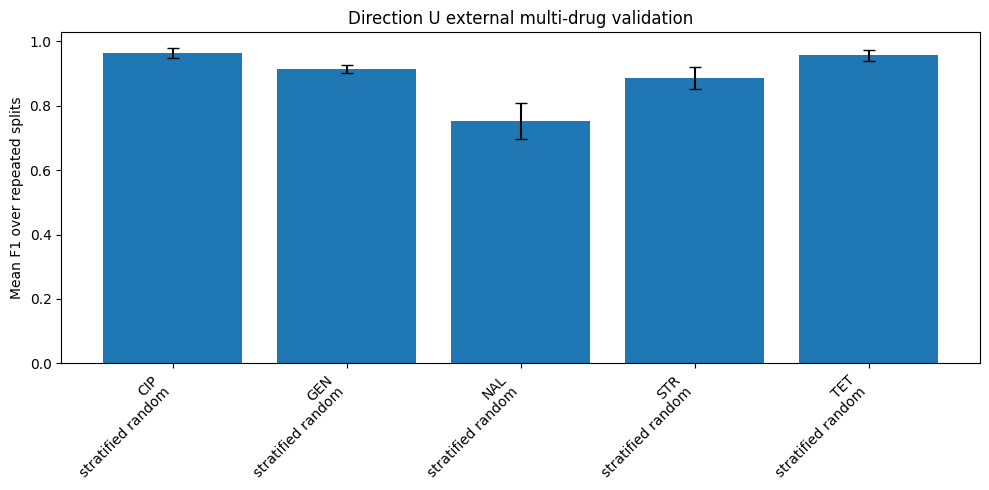

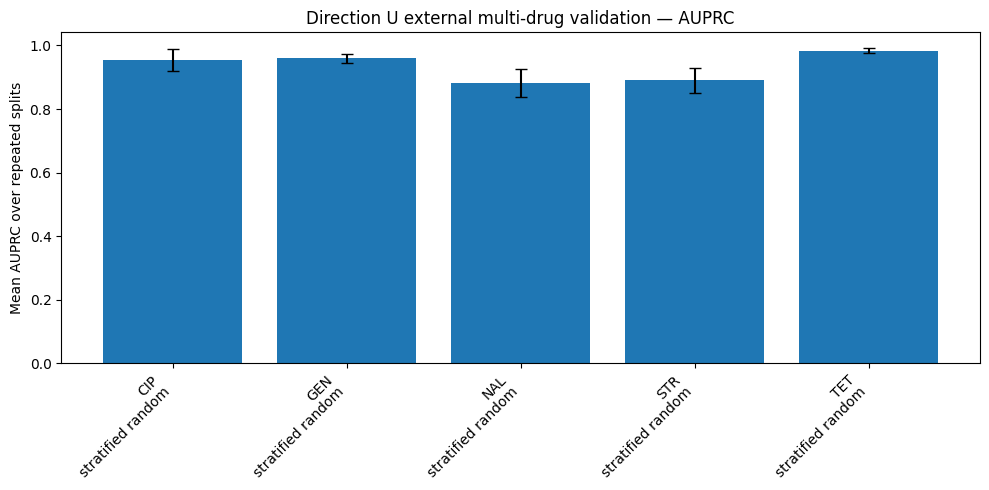

In [12]:

# =========================
# 10. Plots
# =========================

plot_df = best_summary.copy()
plot_df["label"] = plot_df["drug_code"] + "\n" + plot_df["split_mode"].str.replace("_", " ")

plt.figure(figsize=(10, 5))
plt.bar(plot_df["label"], plot_df["f1_mean"], yerr=plot_df["f1_std"].fillna(0), capsize=4)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean F1 over repeated splits")
plt.title("Direction U external multi-drug validation")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "direction_U_best_f1_by_drug.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["label"], plot_df["auprc_mean"], yerr=plot_df["auprc_std"].fillna(0), capsize=4)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean AUPRC over repeated splits")
plt.title("Direction U external multi-drug validation — AUPRC")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "direction_U_best_auprc_by_drug.png", dpi=200)
plt.show()



## 9. Kết luận tự động cho báo cáo

Cell cuối xuất `AUTO_CONCLUSION_DIRECTION_U.md` và file zip outputs.


In [13]:

# =========================
# 11. Auto conclusion + zip
# =========================

lines = []
lines.append("# Direction U — External multi-drug validation")
lines.append("")
lines.append("## Mục tiêu")
lines.append("Direction U phát triển từ Direction T bằng cách kiểm chứng external proof trên nhiều thuốc mới, có repeated split, kiểm tra group-aware nếu metadata đủ dùng, negative control và diễn giải top features bằng keyword cơ chế kháng thuốc.")
lines.append("")
lines.append("## Dữ liệu")
if not dataset_summary.empty:
    for _, r in dataset_summary.iterrows():
        lines.append(f"- {r['drug_code']}: raw S={int(r['raw_S'])}, raw R={int(r['raw_R'])}, usable rows={int(r['usable_rows'])}, features={int(r['n_features'])}.")
else:
    lines.append("- Chưa tạo được dataset summary.")
lines.append("")
lines.append("## Best settings")
for _, r in best_summary.iterrows():
    f1_std = 0 if pd.isna(r.get("f1_std", np.nan)) else r["f1_std"]
    auprc_std = 0 if pd.isna(r.get("auprc_std", np.nan)) else r["auprc_std"]
    lines.append(
        f"- {r['drug_code']} | {r['split_mode']}: best={r['model']} k={int(r['k_features'])}; "
        f"F1={r['f1_mean']:.3f}±{f1_std:.3f}, "
        f"balanced accuracy={r['bal_acc_mean']:.3f}, AUPRC={r['auprc_mean']:.3f}±{auprc_std:.3f}."
    )
lines.append("")
lines.append("## Top feature interpretation")
if not feature_summary_all.empty:
    for drug_code in sorted(feature_summary_all["drug_code"].unique()):
        sub = feature_summary_all[(feature_summary_all["drug_code"] == drug_code) & (feature_summary_all["split_mode"] == "stratified_random")]
        if sub.empty:
            sub = feature_summary_all[feature_summary_all["drug_code"] == drug_code]
        n_direct = int((sub["keyword_label"] == "drug_mechanism_keyword").sum())
        n_general = int((sub["keyword_label"] == "general_amr_or_mobile_keyword").sum())
        examples = sub[sub["keyword_label"] != "unknown_by_keyword"]["feature"].head(3).tolist()
        lines.append(f"- {drug_code}: {n_direct} drug-mechanism keyword features, {n_general} general AMR/mobile keyword features in top list. Examples: {examples}")
else:
    lines.append("- Chưa có bảng top feature annotated.")
lines.append("")
lines.append("## Cách dùng kết quả trong báo cáo")
lines.append("- Nếu nhiều thuốc external đạt F1/AUPRC cao và negative control thấp, dùng Direction U làm bằng chứng mạnh hơn Direction T: external proof không chỉ phụ thuộc vào TET.")
lines.append("- Nếu group-aware thấp hơn random split nhiều, cần trình bày thận trọng: random split có thể bị ảnh hưởng bởi source/serovar similarity.")
lines.append("- Nếu CIP/STR/GEN/NAL có top features đúng cơ chế, bổ sung vào phần biological interpretation để củng cố framework new-drug generalization.")
lines.append("")
lines.append("## Bước tiếp sau U")
lines.append("1. Chạy CARD/ResFinder/AMRFinderPlus cho top features hoặc genome representative.")
lines.append("2. Tạo bảng rule cuối: beta-lactam, quinolone/fluoroquinolone, aminoglycoside, tetracycline, chloramphenicol.")
lines.append("3. Nếu có nhiều thuốc external đủ S/R, train genome-drug model thật sự trên external multi-drug data.")

conclusion = "\n".join(lines)
print(conclusion)

with open(OUTPUT_DIR / "AUTO_CONCLUSION_DIRECTION_U.md", "w", encoding="utf-8") as f:
    f.write(conclusion)

zip_path = BASE_DIR / "salmonella_direction_U_external_multidrug_outputs.zip"
if zip_path.exists():
    zip_path.unlink()
shutil.make_archive(str(zip_path).replace(".zip", ""), "zip", OUTPUT_DIR)

print("\nOutput dir:", OUTPUT_DIR)
print("Zip:", zip_path)

# Nếu chạy trên Colab và muốn tải:
# from google.colab import files
# files.download(str(zip_path))


# Direction U — External multi-drug validation

## Mục tiêu
Direction U phát triển từ Direction T bằng cách kiểm chứng external proof trên nhiều thuốc mới, có repeated split, kiểm tra group-aware nếu metadata đủ dùng, negative control và diễn giải top features bằng keyword cơ chế kháng thuốc.

## Dữ liệu
- TET: raw S=1322, raw R=1545, usable rows=476, features=61226.
- CIP: raw S=2681, raw R=627, usable rows=483, features=55701.
- STR: raw S=1605, raw R=1200, usable rows=475, features=60701.
- GEN: raw S=2307, raw R=309, usable rows=468, features=58675.
- NAL: raw S=2570, raw R=255, usable rows=479, features=63823.

## Best settings
- CIP | stratified_random: best=XGB_weighted k=200; F1=0.963±0.016, balanced accuracy=0.963, AUPRC=0.955±0.035.
- GEN | stratified_random: best=XGB_weighted k=200; F1=0.914±0.014, balanced accuracy=0.918, AUPRC=0.960±0.014.
- NAL | stratified_random: best=LR_balanced k=500; F1=0.752±0.056, balanced accuracy=0.766, AUPRC=0.881±0.044.
- STR | stratified_rando